In [1]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("Stock_Trading_Categorical_Dataset_Large.csv")
df.head()

,No,Tren_Harga,Broker_Summary,Volume_Transaksi,Status_Orderbook,Keputusan
0,1,Sideways,Akumulasi,Tinggi,Kuat Offer,Buy
1,2,Uptrend,Akumulasi,Tinggi,Kuat Bid,Buy
2,3,Sideways,Netral,Tinggi,Kuat Offer,Wait
3,4,Uptrend,Akumulasi,Tinggi,Kuat Bid,Buy
4,5,Uptrend,Netral,Tinggi,Kuat Bid,Buy


In [4]:
# ==========================================
# 1. Dimensi dan tipe data
# ==========================================
print("Dimensi data:", df.shape)
print("\nTipedata:")
print(df.dtypes)


# ==========================================
# 2. Informasi umum
# ==========================================
print("\nInfo umum:")
df.info()

# ==========================================
# 3. Statistik deskriptif kategorikal
# ==========================================
print("\nStatistik deskriptif:")
print(df.describe(include="all"))

# ==========================================
# 4. Cek missing value
# ==========================================
print("\nMissing value setiap kolom:")
print(df.isnull().sum())

print(
    "\nTotal baris dengan minimal 1 missing value:",
    df.isnull().any(axis=1).sum()
)

# ==========================================
# 5. Cek duplikasi baris
# ==========================================
print("\nJumlah baris duplikat:")
print(df.duplicated().sum())

# ==========================================
# 6. Cek nilai unik setiap fitur kategorikal
# ==========================================
categorical_cols = ["Tren_Harga", "Broker_Summary"
                    ,"Volume_Transaksi","Status_Orderbook",
                    "Keputusan"]

print("\nNilai unik setiap kolom kategorikal:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].dropna().unique())
    print("Jumlah kategori:", df[col].dropna().nunique())

# ==========================================
# 7. Cek distribusi target
# ==========================================
print("\nDistribusi target 'Keputusan':")
print(df["Keputusan"].value_counts())

print("\nDistribusi target 'Keputusan' (persentase):")
print(df["Keputusan"].value_counts(normalize=True) * 100)

# ==========================================
# 8. Cek konsistensi penulisan kategori
# ==========================================
print("\nCek konsistensi penulisan kategori(spasi):")
for col in categorical_cols:
    inconsistent = df[col].dropna().astype(str).str.strip().ne(
        df[col].dropna().astype(str)
    ).sum()

    print(f"{col}: {inconsistent} baris tidak konsisten")

# ==========================================
# 9. Cek kombinasi fitur yang duplikat
# ==========================================
feature_cols = ["Tren_Harga", "Broker_Summary", 
                "Volume_Transaksi", "Status_Orderbook"]

print("\nCek kombinasi fitur yang duplikat:")
print(df.duplicated(subset=feature_cols).sum())

# ==========================================
# 10. Cek kombinasi fitur terhadap keputusan
# ==========================================
print("\nCek kombinasi fitur terhadap keputusan:")
print(
    df.groupby(feature_cols)["Keputusan"].value_counts()
)

# ==========================================
# 11. Cek konsistensi aturan
# ==========================================
print("\nCek konsistensi aturan:")
print(
    df.groupby(feature_cols)["Keputusan"].nunique().sort_values(ascending=False)
)

Dimensi data: (1000, 6)

Tipedata:
No                  int64
Tren_Harga            str
Broker_Summary        str
Volume_Transaksi      str
Status_Orderbook      str
Keputusan             str
dtype: object

Info umum:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   No                1000 non-null   int64
 1   Tren_Harga        1000 non-null   str  
 2   Broker_Summary    1000 non-null   str  
 3   Volume_Transaksi  1000 non-null   str  
 4   Status_Orderbook  1000 non-null   str  
 5   Keputusan         1000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 47.0 KB

Statistik deskriptif:
                 No Tren_Harga Broker_Summary Volume_Transaksi  \
count   1000.000000       1000           1000             1000   
unique          NaN          3              3                2   
top             NaN   Sideways         Netral           Tingg

In [5]:
# ==========================================
# Pengecekan Valid Categories
# ==========================================
valid_categories = {
    "Tren_Harga": ["Uptrend", "Downtrend", "Sideways"],
    "Broker_Summary": ["Akumulasi", "Distribusi", "Netral"],
    "Volume_Transaksi": ["Tinggi", "Rendah"],
    "Status_Orderbook": ["Kuat Bid", "Kuat Offer"],
    "Keputusan": ["Buy", "Wait"]
}

for col, valid_values in valid_categories.items():
    invalid_values = sorted(set(df[col].dropna().astype(str)) - set(valid_values))

    if invalid_values:
        print(f"\nKolom '{col}' memiliki nilai yang tidak sesuai kategori:")
        print(invalid_values)
    else:
        print(f"\nKolom '{col}' semua nilai sesuai kategori.")


Kolom 'Tren_Harga' semua nilai sesuai kategori.

Kolom 'Broker_Summary' semua nilai sesuai kategori.

Kolom 'Volume_Transaksi' semua nilai sesuai kategori.

Kolom 'Status_Orderbook' semua nilai sesuai kategori.

Kolom 'Keputusan' semua nilai sesuai kategori.


In [6]:
# ==========================================
# Cek Missing Value
# ==========================================
print("\nCek Missing Value sebelum diprocessing:")
print(df.isnull().sum())

print(
    "\nTotal baris dengan minimal 1 missing value:",
    df.isnull().any(axis=1).sum()
)

# ==========================================
# Drop Missing Value
# ==========================================
df.dropna(subset=["Keputusan"], inplace=True)

# ==========================================
# Impute Missing Value (menggunakan modus)
# ==========================================
feature_cols = ["Tren_Harga", "Broker_Summary", "Volume_Transaksi", "Status_Orderbook"]

for col in feature_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# ==========================================
# Cek Missing Value setelah diprocessing
# ==========================================
print("\nCek Missing Value setelah diprocessing:")
print(df.isnull().sum())


Cek Missing Value sebelum diprocessing:
No                  0
Tren_Harga          0
Broker_Summary      0
Volume_Transaksi    0
Status_Orderbook    0
Keputusan           0
dtype: int64

Total baris dengan minimal 1 missing value: 0

Cek Missing Value setelah diprocessing:
No                  0
Tren_Harga          0
Broker_Summary      0
Volume_Transaksi    0
Status_Orderbook    0
Keputusan           0
dtype: int64


In [7]:
assert df.isnull().sum().sum() == 0, "Masih ada missing value!"
df_clean =df.drop(columns=["No"])
print("Data sudah bersih dan siap untuk tahap selection & Transformation.")

Data sudah bersih dan siap untuk tahap selection & Transformation.


In [8]:
import pandas as pd

# Mendefinisikan Fitur Kategorikal (Variabel Independen / X)
categorical_cols = [
    "Tren_Harga", 
    "Broker_Summary", 
    "Volume_Transaksi", 
    "Status_Orderbook"
]

# Mendefinisikan Target Prediksi (Variabel Dependen / y)
target_col = ["Keputusan"]

# Membuat DataFrame baru yang bersih
df_saham_selected = df[categorical_cols + target_col].copy()

# Mengecek hasil akhir
print(df_saham_selected.head())

  Tren_Harga Broker_Summary Volume_Transaksi Status_Orderbook Keputusan
0   Sideways      Akumulasi           Tinggi       Kuat Offer       Buy
1    Uptrend      Akumulasi           Tinggi         Kuat Bid       Buy
2   Sideways         Netral           Tinggi       Kuat Offer      Wait
3    Uptrend      Akumulasi           Tinggi         Kuat Bid       Buy
4    Uptrend         Netral           Tinggi         Kuat Bid       Buy


In [9]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Menginisialisasi model OneHotEncoder
# sparse_output=False mengubah hasilnya langsung menjadi array matriks biasa
encoder = OneHotEncoder(sparse_output=False)

# 2. Melakukan proses encoding HANYA pada fitur kategorikal (X)
encoded_data = encoder.fit_transform(df_saham_selected[categorical_cols])

# 3. Mengambil nama-nama kolom baru hasil pecahan encoding
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# 4. Membuat DataFrame baru berisi angka 0 dan 1
df_encoded = pd.DataFrame(encoded_data, columns=encoded_cols)

# 5. Menggabungkan kembali kolom target 'Keputusan' yang tidak ikut di-encode
# (Menggunakan reset_index untuk mencegah data bergeser)
df_encoded['Keputusan'] = df_saham_selected['Keputusan'].reset_index(drop=True)

# 6. Cek hasil akhir
df_encoded.head()

,Tren_Harga_Downtrend,Tren_Harga_Sideways,Tren_Harga_Uptrend,Broker_Summary_Akumulasi,Broker_Summary_Distribusi,Broker_Summary_Netral,Volume_Transaksi_Rendah,Volume_Transaksi_Tinggi,Status_Orderbook_Kuat Bid,Status_Orderbook_Kuat Offer,Keputusan
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,Buy
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,Buy
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,Wait
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,Buy
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,Buy


In [10]:
from sklearn.model_selection import train_test_split

# 1. Mendefinisikan ulang X dan y dari data yang sudah di-encode
# X adalah semua kolom kecuali kolom target 'Keputusan'
X_final = df_encoded.drop(columns=['Keputusan'])

# y adalah kolom target 'Keputusan'
y_final = df_encoded['Keputusan']

# 2. Membagi data (Contoh: 80% untuk latih, 20% untuk uji)
# random_state=42 digunakan agar pembagian acak ini tetap sama setiap kali kode dijalankan
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Cek jumlah pembagian data
print(f"Jumlah data latih (Training): {X_train.shape[0]} baris")
print(f"Jumlah data uji (Testing): {X_test.shape[0]} baris")

Jumlah data latih (Training): 800 baris
Jumlah data uji (Testing): 200 baris


In [11]:
from sklearn.tree import DecisionTreeClassifier

# 1. Menginisialisasi model Decision Tree dengan kriteria Entropy (ID3)
# max_depth bisa diatur nanti untuk mencegah model terlalu rumit (overfitting)
model_id3 = DecisionTreeClassifier(criterion="entropy", random_state=42)

# 2. Melatih model menggunakan data latih
model_id3.fit(X_train, y_train)

print("Model Decision Tree (ID3) berhasil dilatih!")

Model Decision Tree (ID3) berhasil dilatih!


In [12]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Meminta model untuk memprediksi data uji (X_test)
y_pred = model_id3.predict(X_test)

# 2. Menghitung skor akurasi (membandingkan tebakan dengan jawaban asli di y_test)
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%\n")

# 3. Menampilkan laporan performa detail
print("=== Laporan Klasifikasi ===")
print(classification_report(y_test, y_pred))

Akurasi Model: 100.00%

=== Laporan Klasifikasi ===
              precision    recall  f1-score   support

         Buy       1.00      1.00      1.00       101
        Wait       1.00      1.00      1.00        99

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import joblib

# Menyiapkan data mentah dari dataset yang sudah diperbarui
X_mentah = df_saham_selected[categorical_cols].copy()
y_mentah = df_saham_selected["Keputusan"].copy()

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
classifier = DecisionTreeClassifier(criterion="entropy", random_state=42)

model_pipeline = Pipeline([
    ("preprocessor", encoder),
    ("classifier", classifier)
])

model_pipeline.fit(X_mentah, y_mentah)
joblib.dump(model_pipeline, "mymodel.pkl")

print("Pipeline berhasil dilatih ulang dari dataset terbaru.")
print("Distribusi target:")
print(y_mentah.value_counts())
print("Model terbaru berhasil disimpan ke 'mymodel.pkl'.")

Pipeline berhasil dilatih ulang dari dataset terbaru.
Distribusi target:
Keputusan
Buy     534
Wait    466
Name: count, dtype: int64
Model terbaru berhasil disimpan ke 'mymodel.pkl'.


Fitur yang digunakan dalam split tree:
- Tren_Harga_Uptrend: 0.2579
- Broker_Summary_Akumulasi: 0.2253
- Volume_Transaksi_Rendah: 0.2473
- Volume_Transaksi_Tinggi: 0.0752
- Status_Orderbook_Kuat Bid: 0.1943


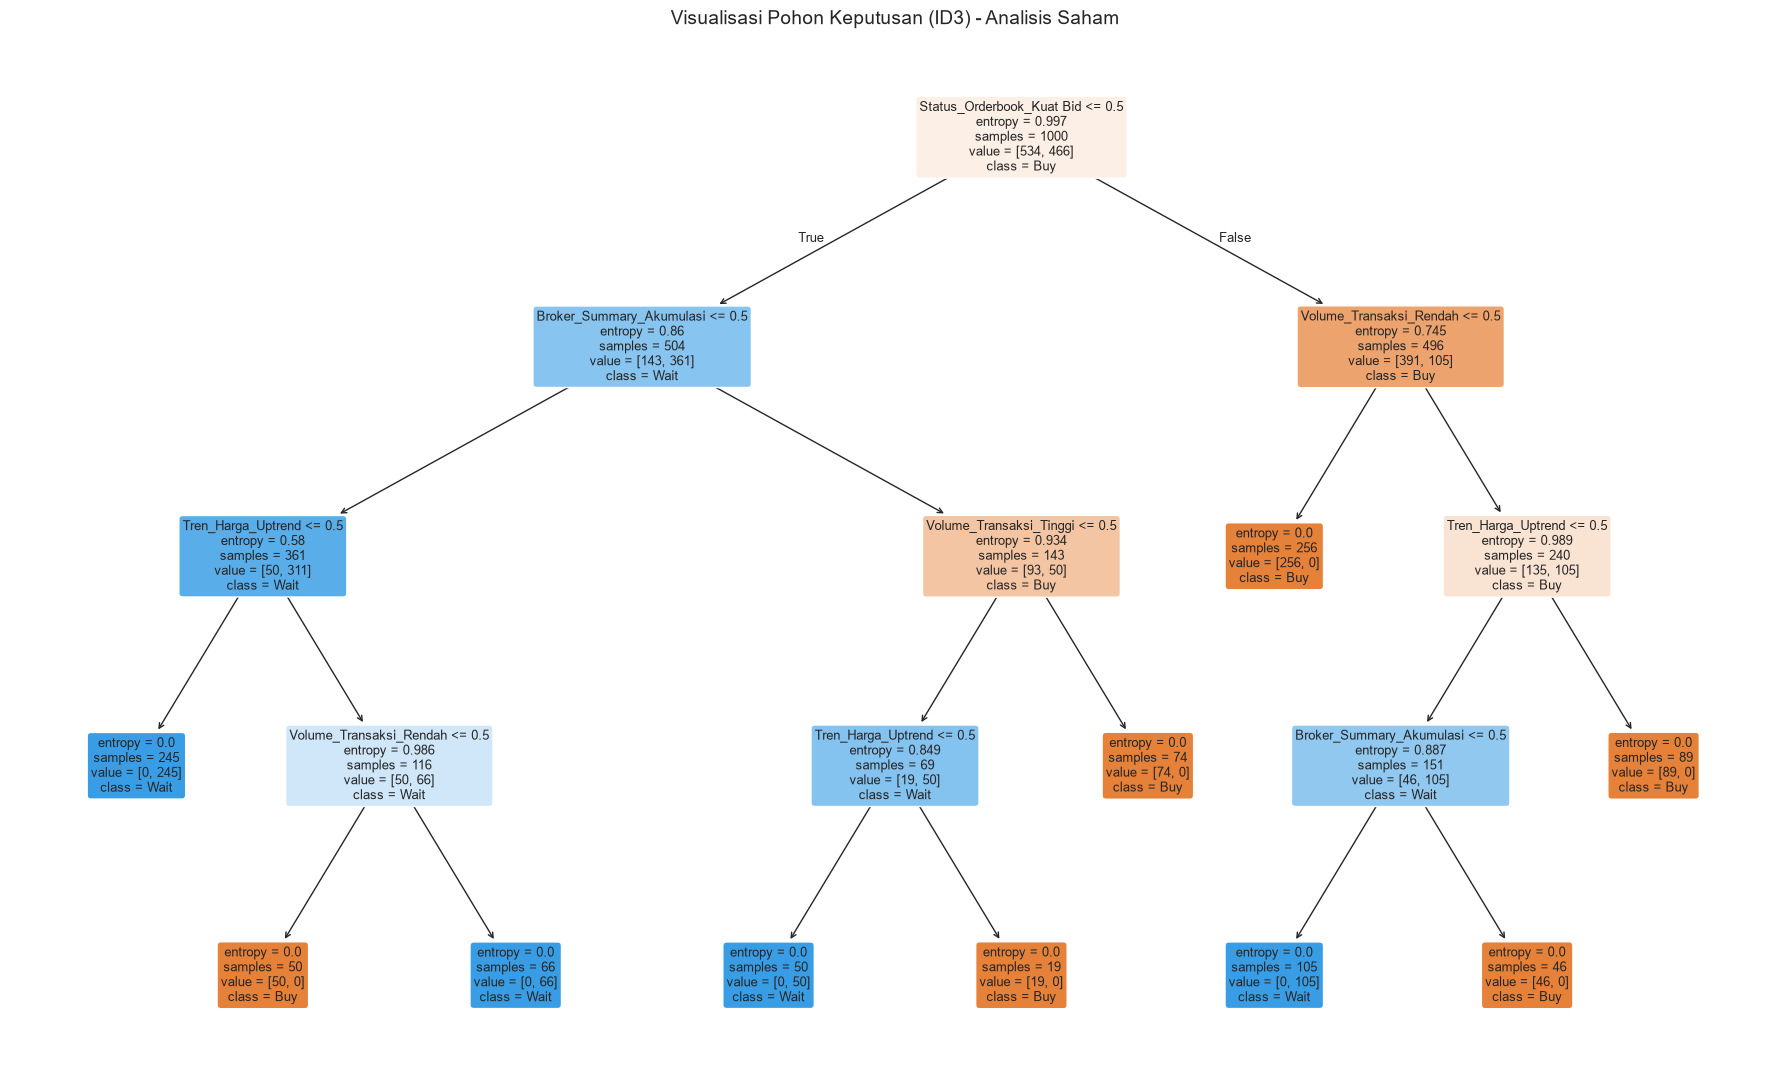

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Mengambil model terbaru dari pipeline hasil retraining
# Jalankan cell training terlebih dahulu sebelum cell ini.
tree_model = model_pipeline.named_steps["classifier"]
nama_fitur = model_pipeline.named_steps["preprocessor"].get_feature_names_out(categorical_cols)

print("Fitur yang digunakan dalam split tree:")
for nama, importance in zip(nama_fitur, tree_model.feature_importances_):
    if importance > 0:
        print(f"- {nama}: {importance:.4f}")

plt.figure(figsize=(18, 11))
plot_tree(
    tree_model,
    feature_names=nama_fitur,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Visualisasi Pohon Keputusan (ID3) - Analisis Saham", fontsize=14)
plt.tight_layout()
plt.savefig("tree.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
from sklearn.tree import export_text

# Mengekstrak aturan dari model pipeline terbaru
tree_model = model_pipeline.named_steps["classifier"]
nama_fitur = model_pipeline.named_steps["preprocessor"].get_feature_names_out(categorical_cols).tolist()
tree_rules = export_text(tree_model, feature_names=nama_fitur)

print("=== ATURAN KEPUTUSAN (IF-THEN) ===")
print(tree_rules)

with open("rules.txt", "w", encoding="utf-8") as file:
    file.write(tree_rules)

print("Aturan terbaru berhasil disimpan ke 'rules.txt'.")
print("Volume digunakan dalam aturan:", "Volume_Transaksi" in tree_rules)

=== ATURAN KEPUTUSAN (IF-THEN) ===
|--- Status_Orderbook_Kuat Bid <= 0.50
|   |--- Broker_Summary_Akumulasi <= 0.50
|   |   |--- Tren_Harga_Uptrend <= 0.50
|   |   |   |--- class: Wait
|   |   |--- Tren_Harga_Uptrend >  0.50
|   |   |   |--- Volume_Transaksi_Rendah <= 0.50
|   |   |   |   |--- class: Buy
|   |   |   |--- Volume_Transaksi_Rendah >  0.50
|   |   |   |   |--- class: Wait
|   |--- Broker_Summary_Akumulasi >  0.50
|   |   |--- Volume_Transaksi_Tinggi <= 0.50
|   |   |   |--- Tren_Harga_Uptrend <= 0.50
|   |   |   |   |--- class: Wait
|   |   |   |--- Tren_Harga_Uptrend >  0.50
|   |   |   |   |--- class: Buy
|   |   |--- Volume_Transaksi_Tinggi >  0.50
|   |   |   |--- class: Buy
|--- Status_Orderbook_Kuat Bid >  0.50
|   |--- Volume_Transaksi_Rendah <= 0.50
|   |   |--- class: Buy
|   |--- Volume_Transaksi_Rendah >  0.50
|   |   |--- Tren_Harga_Uptrend <= 0.50
|   |   |   |--- Broker_Summary_Akumulasi <= 0.50
|   |   |   |   |--- class: Wait
|   |   |   |--- Broker_Summary

In [19]:
import numpy as np
from sklearn.tree import _tree

tree_model = model_pipeline.named_steps["classifier"]
nama_fitur = model_pipeline.named_steps["preprocessor"].get_feature_names_out(categorical_cols).tolist()
human_rules = []

print("Jumlah node tree:", tree_model.tree_.node_count)
print("Root feature index:", tree_model.tree_.feature[0])


def cetak_aturan_manusia(model_tree, daftar_fitur, daftar_kelas):
    tree_ = model_tree.tree_

    def telusuri_cabang(node, aturan_sekarang):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            nama_kolom = daftar_fitur[tree_.feature[node]]
            bagian = nama_kolom.rsplit("_", 1)
            kategori = bagian[0].replace("_", " ")
            nilai = bagian[1]
            telusuri_cabang(tree_.children_left[node], aturan_sekarang + [f"{kategori} BUKAN {nilai}"])
            telusuri_cabang(tree_.children_right[node], aturan_sekarang + [f"{kategori} ADALAH {nilai}"])
        else:
            keputusan = daftar_kelas[np.argmax(tree_.value[node][0])]
            human_rules.append(f"JIKA {' DAN '.join(aturan_sekarang)}\nMAKA Keputusan = {keputusan}")

    telusuri_cabang(0, [])

print("=== ATURAN IF-THEN (BAHASA MANUSIA) ===\n")
cetak_aturan_manusia(tree_model, nama_fitur, tree_model.classes_)
print("\n\n".join(human_rules))
with open("rules_human.txt", "w", encoding="utf-8") as file:
    file.write("\n\n".join(human_rules))
print(f"{len(human_rules)} aturan lengkap berhasil disimpan ke 'rules_human.txt'.")

Jumlah node tree: 19
Root feature index: 8
=== ATURAN IF-THEN (BAHASA MANUSIA) ===

JIKA Status Orderbook BUKAN Kuat Bid DAN Broker Summary BUKAN Akumulasi DAN Tren Harga BUKAN Uptrend
MAKA Keputusan = Wait

JIKA Status Orderbook BUKAN Kuat Bid DAN Broker Summary BUKAN Akumulasi DAN Tren Harga ADALAH Uptrend DAN Volume Transaksi BUKAN Rendah
MAKA Keputusan = Buy

JIKA Status Orderbook BUKAN Kuat Bid DAN Broker Summary BUKAN Akumulasi DAN Tren Harga ADALAH Uptrend DAN Volume Transaksi ADALAH Rendah
MAKA Keputusan = Wait

JIKA Status Orderbook BUKAN Kuat Bid DAN Broker Summary ADALAH Akumulasi DAN Volume Transaksi BUKAN Tinggi DAN Tren Harga BUKAN Uptrend
MAKA Keputusan = Wait

JIKA Status Orderbook BUKAN Kuat Bid DAN Broker Summary ADALAH Akumulasi DAN Volume Transaksi BUKAN Tinggi DAN Tren Harga ADALAH Uptrend
MAKA Keputusan = Buy

JIKA Status Orderbook BUKAN Kuat Bid DAN Broker Summary ADALAH Akumulasi DAN Volume Transaksi ADALAH Tinggi
MAKA Keputusan = Buy

JIKA Status Orderbook ADAL